In [ ]:
# Variance threshold
# K best features (filter method)
# Recursive feature elimination
# RFE
# Boruta

In [ ]:
#Why do feature select
# At equal performance, a simpler model is a better model
#faster
# Improve the model's performance
# Before hyperparameter tuning and model selection

In [ ]:
# Variance threshold

In [ ]:
import pandas as pd
import pandas as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

%matplotlib inline

In [ ]:
plt.rcparam[-'figure.figsize'] = (12,9)

In [ ]:
Read the Data

In [ ]:
wine_data = load_wine()

In [2]:
import pandas as pd
from sklearn.datasets import load_wine

wine_data = load_wine()
wine_df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target

wine_df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 29.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 28.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='features', ylabel='value'>

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


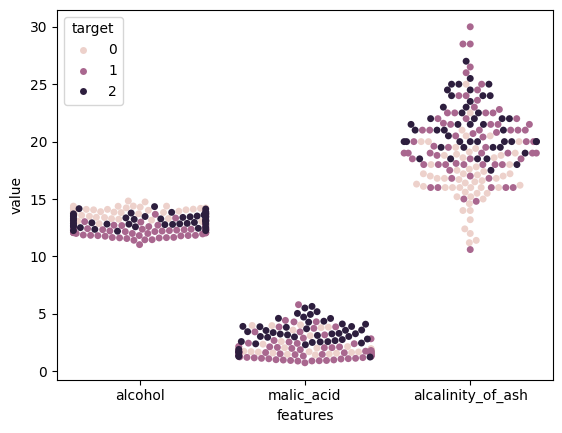

In [5]:
from seaborn import swarmplot

data_to_plot = pd.melt(
    wine_df[['alcohol', 'malic_acid', 'alcalinity_of_ash', 'target']],
    id_vars='target',
    var_name='features',   # corrected spelling
    value_name='value'
)

swarmplot(data=data_to_plot, x='features', y='value', hue='target')



In [3]:
wine_df['target'].value_counts()

,count
target,
1,71
0,59
2,48


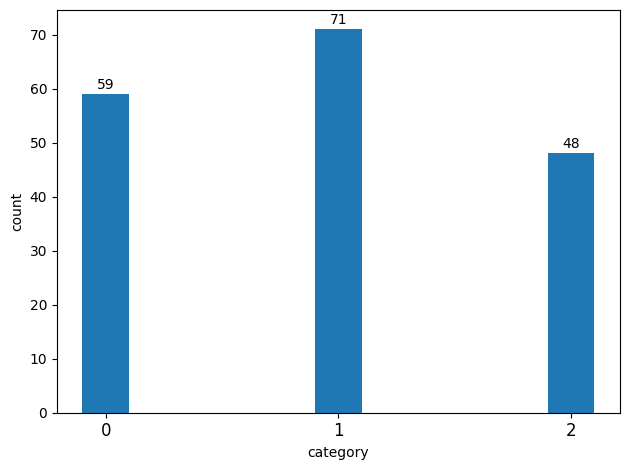

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = [0, 1, 2]
y = [59, 71, 48]

ax.bar(x, y, width=0.2)
ax.set_xlabel('category')
ax.set_ylabel('count')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([0, 1, 2], fontsize=12)

for index, value in enumerate(y):
    plt.text(x=index, y=value+1, s=str(value), ha='center')

plt.tight_layout()
plt.show()


In [ ]:
#Train/test split

In [8]:
from sklearn.model_selection import train_test_split
x = wine_df.drop(['target'], axis=1)
y =wine_df['target']
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=42)
print(x_train.shape)
print(x_test.shape)

(124, 13)
(54, 13)


In [ ]:
#Baseline Model: Gradient Boosting classifier with all features

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# initialize classifier
gbc = GradientBoostingClassifier(max_depth=5, random_state=42)

# train classifier using all features
gbc.fit(x_train, y_train)

# make predictions
preds = gbc.predict(x_test)

# evaluate the model using the F1 score
f1_score_all = round(f1_score(y_test, preds, average='weighted'), 3)

print(f1_score_all)



0.908


In [ ]:
#feature selection techniques
#Variance Threshold
# variance is a measure of spread from mean
# if the variance is 0, then we have  a feature with constant value
# if the feature has a variance of 0, then it is likely not predictive

In [13]:
x_train_v1, x_test_v1, y_train_v1, y_test_v1 = (
    x_train.copy(),
    x_test.copy(),
    y_train.copy(),
    y_test.copy()
)


In [14]:
#calculate the variance of each feature
x_train_v1.var(axis=0)

,0
alcohol,0.658341
malic_acid,1.123507
ash,0.072433
alcalinity_of_ash,11.471279
magnesium,232.071532
total_phenols,0.393226
flavanoids,0.912299
nonflavanoid_phenols,0.013873
proanthocyanins,0.335108
color_intensity,5.669722


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_x_trian_v1 = scaler.fit_transform(x_train_v1)


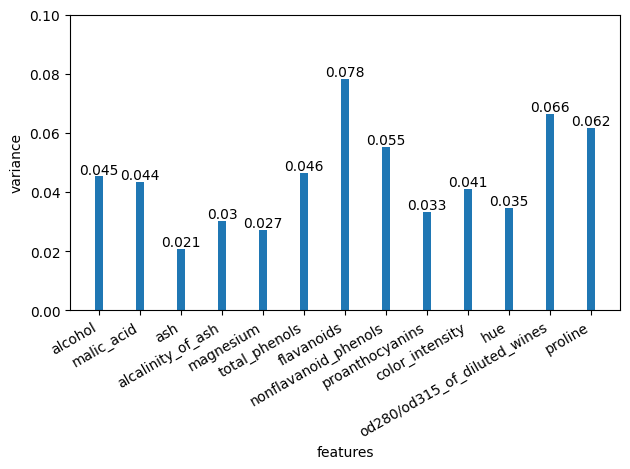

In [20]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# scale the training set correctly
scaled_x_train_v1 = scaler.fit_transform(x_train_v1)

fig, ax = plt.subplots()

# use the original DataFrame's column names
x = x_train_v1.columns
y = scaled_x_train_v1.var(axis=0)

ax.bar(x, y, width=0.2)
ax.set_xlabel('features')
ax.set_ylabel('variance')
ax.set_ylim(0, 0.1)

# add variance values above each bar
for index, value in enumerate(y):
    plt.text(x=index, y=value+0.001, s=str(round(value, 3)), ha='center')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [22]:
sel_x_train_v1 = x_train_v1.drop(['ash', 'magnesium'], axis=1)
sel_x_test_v1 = x_test_v1.drop(['ash', 'magnesium'], axis=1)

# Train on training features and labels
gbc.fit(sel_x_train_v1, y_train_v1)

# Predict on test features
vars_preds = gbc.predict(sel_x_test_v1)

# Evaluate
f1_score_var = round(f1_score(y_test_v1, vars_preds, average='weighted'), 3)
print(f1_score_var)


0.963


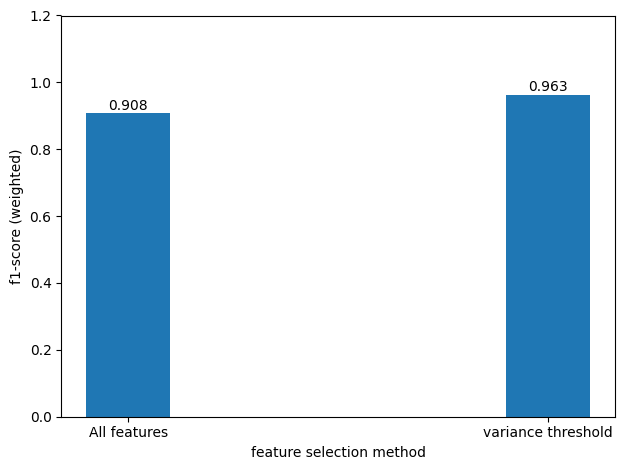

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = ['All features', 'variance threshold']
y = [f1_score_all, f1_score_var]

ax.bar(x, y, width=0.2)
ax.set_xlabel('feature selection method')
ax.set_ylabel("f1-score (weighted)")
ax.set_ylim(0, 1.2)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.01, s=str(round(value, 3)), ha='center')

plt.tight_layout()
plt.show()



In [ ]:
# K best features methode
# use a measure of importance to slect the top k features

In [ ]:
x_train_v1, x_test_v1, y_train_v1, y_test_v1 = (
    x_train.copy(),
    x_test.copy(),
    y_train.copy(),
    y_test.copy()
)

In [27]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import f1_score

f1_score_list = []

for k in range(1, 14):
    # use v1 variables consistently
    selector = SelectKBest(mutual_info_classif, k=k)
    selector.fit(x_train_v1, y_train_v1)

    sel_x_train_v1 = selector.transform(x_train_v1)
    sel_x_test_v1 = selector.transform(x_test_v1)

    gbc.fit(sel_x_train_v1, y_train_v1)
    kbest_preds = gbc.predict(sel_x_test_v1)

    f1_score_kbest = round(f1_score(y_test_v1, kbest_preds, average='weighted'), 3)
    f1_score_list.append(f1_score_kbest)

print(f1_score_list)


[0.759, 0.926, 0.981, 0.981, 0.981, 0.981, 0.981, 0.963, 0.963, 0.963, 0.945, 0.908, 0.908]


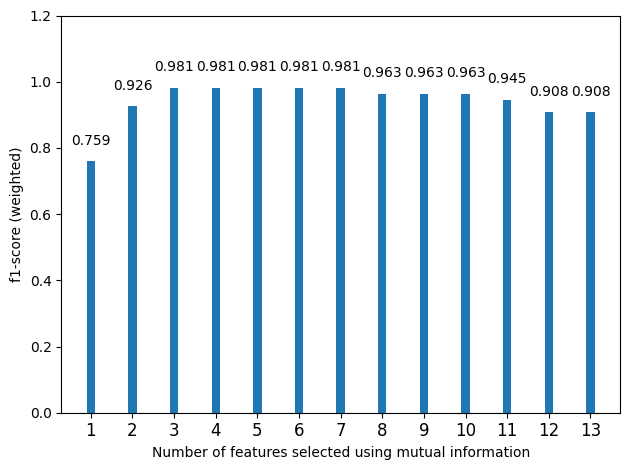

In [30]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = np.arange(1, 14)
y = f1_score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('f1-score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize=12)

for i, v in enumerate(y):
    plt.text(x=i+1, y=v+0.05, s=str(round(v, 3)), ha='center')

plt.tight_layout()
plt.show()


In [34]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Initialize the selector
selector = SelectKBest(mutual_info_classif, k=3)

# Fit on your training data (make sure x_train_v1 and y_train_v1 are defined)
selector.fit(x_train_v1, y_train_v1)

# Get the mask of selected features
selected_features_mask = selector.get_support()

# Apply the mask to the DataFrame's columns to get names
selected_features = x_train_v1.columns[selected_features_mask]

print(selected_features)




Index(['flavanoids', 'color_intensity', 'proline'], dtype='object')


In [ ]:
# Recursive festure elimination RFE
# a wrapper method that uses the model to calculate the feature importance
# must use a model that has a way of calculating features impoarnace (tree-based model)

In [ ]:
x_train_v3, x_test_v3, y_train_v3, y_test_v3 = (
    x_train.copy(),
    x_test.copy(),
    y_train.copy(),
    y_test.copy()
)

In [38]:
# First, define v3 variables (copies of your train/test sets)
x_train_v3, x_test_v3, y_train_v3, y_test_v3 = (
    x_train.copy(),
    x_test.copy(),
    y_train.copy(),
    y_test.copy()
)

from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score

rfe_f1_score_list = []

for k in range(1, 14):
    # Correct spelling of parameter: n_features_to_select
    RFE_selector = RFE(estimator=gbc, n_features_to_select=k, step=1)
    RFE_selector.fit(x_train_v3, y_train_v3)

    # Transform train and test sets
    sel_x_train_v3 = RFE_selector.transform(x_train_v3)
    sel_x_test_v3 = RFE_selector.transform(x_test_v3)

    # Fit model on selected features
    gbc.fit(sel_x_train_v3, y_train_v3)
    RFE_preds = gbc.predict(sel_x_test_v3)

    # Compute weighted F1 score
    f1_score_rfe = round(f1_score(y_test_v3, RFE_preds, average='weighted'), 3)
    rfe_f1_score_list.append(f1_score_rfe)

print(rfe_f1_score_list)



[0.622, 0.85, 1.0, 0.981, 0.963, 0.963, 0.869, 0.908, 0.908, 0.908, 0.908, 0.908, 0.908]


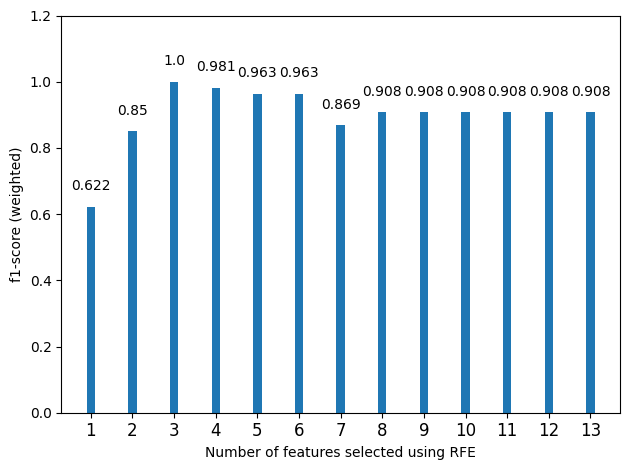

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x = np.arange(1, 14)
y = rfe_f1_score_list

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('f1-score (weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1, 14))
ax.set_xticklabels(np.arange(1, 14), fontsize=12)

for i, v in enumerate(y):
    plt.text(x=i+1, y=v+0.05, s=str(round(v, 3)), ha='center')

plt.tight_layout()
plt.show()


In [41]:
from sklearn.feature_selection import RFE

rfe_selector = RFE(estimator=gbc, n_features_to_select=3, step=10)
rfe_selector.fit(x_train_v1, y_train_v1)

selected_features_mask = rfe_selector.get_support()
selected_features = x_train_v1.columns[selected_features_mask]

print(selected_features)


Index(['color_intensity', 'od280/od315_of_diluted_wines', 'proline'], dtype='object')


In [ ]:
# Boruta: this take the human out
# a feature selection algorithm where we do not need to set a subjective threshold

In [ ]:
# Install boruta-py
!pip install boruta




In [2]:
!pip install boruta



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.4 MB/s eta 0:00:00


In [3]:
from boruta import BorutaPy


In [8]:


import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from boruta import BorutaPy

# 1. Load a sample dataset (replace with your own DataFrame if you have one)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 2. Split into train/test sets
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Define base estimator
gbc = GradientBoostingClassifier(random_state=42)

# 4. Initialize Boruta
boruta_selector = BorutaPy(estimator=gbc, random_state=42)

# 5. Fit Boruta on training data (Boruta expects numpy arrays)
boruta_selector.fit(x_train.values, y_train.values.ravel())

# 6. Transform train and test sets
sel_x_train = boruta_selector.transform(x_train.values)
sel_x_test = boruta_selector.transform(x_test.values)

# 7. Train and predict
gbc.fit(sel_x_train, y_train)
boruta_preds = gbc.predict(sel_x_test)

# 8. Evaluate
boruta_f1_score = round(f1_score(y_test, boruta_preds, average='weighted'), 3)
print("Boruta F1 Score:", boruta_f1_score)

# 9 Get selected features
selected_features_mask = boruta_selector.support_
selected_features = x_train.columns[selected_features_mask]
print("Selected Features:", selected_features)


Boruta F1 Score: 0.947
Selected Features: Index(['mean texture', 'mean concave points', 'radius error',
       'concavity error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst concavity', 'worst concave points'],
      dtype='object')


In [9]:


from boruta import BorutaPy
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# Make sure you already have x_train, x_test, y_train, y_test defined
x_train_v4, x_test_v4, y_train_v4, y_test_v4 = (
    x_train.copy(),
    x_test.copy(),
    y_train.copy(),
    y_test.copy()
)

# 1. Define your base estimator
gbc = GradientBoostingClassifier(random_state=42)

# 2. Initialize Boruta with the estimator
boruta_selector = BorutaPy(estimator=gbc, random_state=42)

# 3. Fit Boruta on training data (Boruta expects numpy arrays)
boruta_selector.fit(x_train_v4.values, y_train_v4.values.ravel())

# 4. Transform train and test sets to keep only selected features
sel_x_train_v4 = boruta_selector.transform(x_train_v4.values)
sel_x_test_v4 = boruta_selector.transform(x_test_v4.values)

# 5. Train the model on selected features
gbc.fit(sel_x_train_v4, y_train_v4)

# 6. Predict on test set
boruta_preds = gbc.predict(sel_x_test_v4)

# 7. Evaluate with weighted F1 score
boruta_f1_score = round(f1_score(y_test_v4, boruta_preds, average='weighted'), 3)
print("Boruta F1 Score:", boruta_f1_score)

# 8. Get names of selected features
selected_features_mask = boruta_selector.support_
selected_features = x_train_v4.columns[selected_features_mask]
print("Selected Features:", selected_features)



Boruta F1 Score: 0.947
Selected Features: Index(['mean texture', 'mean concave points', 'radius error',
       'concavity error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst concavity', 'worst concave points'],
      dtype='object')


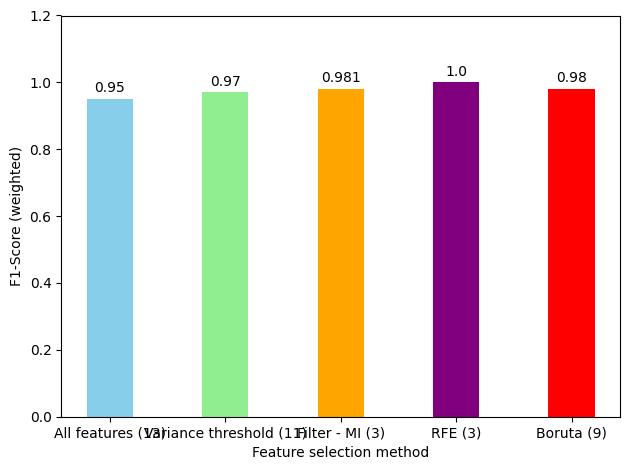

In [14]:
import matplotlib.pyplot as plt

# Define your F1 scores first (replace these with your actual computed values)
f1_score_all = 0.95
f1_score_var = 0.97
boruta_f1_score = 0.98

fig, ax = plt.subplots()

x = ['All features (13)', 'Variance threshold (11)', 'Filter - MI (3)', 'RFE (3)', 'Boruta (9)']
y = [f1_score_all, f1_score_var, 0.981, 1.0, boruta_f1_score]

# Create bar chart
ax.bar(x, y, width=0.4, color=['skyblue', 'lightgreen', 'orange', 'purple', 'red'])

# Labels and limits
ax.set_xlabel('Feature selection method')
ax.set_ylabel('F1-Score (weighted)')
ax.set_ylim(0, 1.2)

# Annotate each bar with its value (rounded to 3 decimals)
for i, v in enumerate(y):
    ax.text(i, v + 0.02, str(round(v, 3)), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [16]:
 # Importing the libraries
import pandas as pd
import numpy as np



In [ ]:
#Loading the Data

In [17]:


# Dataset URL
data = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names
features = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# Load into DataFrame
df = pd.read_csv(data, names=features)

# Quick check
print(df.head())


   preg  plas  pres  skin  test  mass   pedi  age  class
0     6   148    72    35     0  33.6  0.627   50      1
1     1    85    66    29     0  26.6  0.351   31      0
2     8   183    64     0     0  23.3  0.672   32      1
3     1    89    66    23    94  28.1  0.167   21      0
4     0   137    40    35   168  43.1  2.288   33      1


In [18]:
df.shape

(768, 9)

In [19]:
#Preparing the Data

data = df.values
X = data[:,0:8]
Y = data[:,8]

In [20]:
#Filter Method
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# Feature extraction
chi_best = SelectKBest(score_func=chi2, k=4)
k_best = chi_best.fit(X, Y)

In [21]:
# Summarize scores
np.set_printoptions(precision=3)
print(k_best.scores_)

k_features = k_best.transform(X)
# Summarize selected features
print(k_features[0:5,:])

[ 111.52  1411.887   17.605   53.108 2175.565  127.669    5.393  181.304]
[[148.    0.   33.6  50. ]
 [ 85.    0.   26.6  31. ]
 [183.    0.   23.3  32. ]
 [ 89.   94.   28.1  21. ]
 [137.  168.   43.1  33. ]]


In [ ]:
# Wrapper Method
# Recursive Feature Elimination (RFE)

In [22]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Feature extraction
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Define your model
model_lr = LogisticRegression(max_iter=1000)

# Initialize RFE with the model and number of features to select
recur_fe = RFE(estimator=model_lr, n_features_to_select=3)

# Fit RFE
Feature = recur_fe.fit(X, Y)

# Print results
print("Number of Features: %s" % Feature.n_features_)
print("Selected Features are : %s" % Feature.support_)
print("Feature Ranking is as follows: %s" % Feature.ranking_)


Number of Features: 3
Selected Features are : [ True False False False False  True  True False]
Feature Ranking is as follows: [1 2 4 6 5 1 1 3]


In [ ]:
# Embedded Method
# Ridge Regression / L2 Regularization

In [26]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X,Y)
Ridge()

Ridge()

In [27]:
# A helper function for printing the coefficients
def print_coefs(coef, names = None, sort = False):
    if names == None:
        names = ["X%s" % x for x in range(len(coef))]
    lst = zip(coef, names)
    if sort:
        lst = sorted(lst, key = lambda x:-np.abs(x[0]))
    return " + ".join("%s * %s" % (round(coefs, 3), name)
                      for coefs, name in lst)

In [28]:
print("Ridge model:", print_coefs(ridge_reg.coef_))

Ridge model: 0.021 * X0 + 0.006 * X1 + -0.002 * X2 + 0.0 * X3 + -0.0 * X4 + 0.013 * X5 + 0.145 * X6 + 0.003 * X7
